In [1]:
import sys
import os
import pandas as pd

current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
if parent_dir not in sys.path:
    sys.path.append(parent_dir)
%load_ext autoreload
%autoreload 2

In [2]:
from hep_rewgt_tk.reweight_app import SingleXGBReweighter
from hep_rewgt_tk.reweight_nn import GANReweighter

## Pre-clean datasets

In [3]:
def apply_all(dir_name, func):
    dfA = func(pd.read_csv(f'{dir_name}/RegionA.csv', index_col=0))
    dfB = func(pd.read_csv(f'{dir_name}/RegionB.csv', index_col=0))
    dfC = func(pd.read_csv(f'{dir_name}/RegionC.csv', index_col=0))
    dfD = func(pd.read_csv(f'{dir_name}/RegionD.csv', index_col=0)) 
    return dfA, dfB, dfC, dfD

In [4]:
ABCD_dir = "/Users/yuntongzhou/Desktop/Dihiggszztt/output/ABCD"

In [5]:
def keep_fake_ttbar(df):
    df = df[df.group=='TTbar']
    cond_1 = df['LDTau_genflav'] < 5
    cond_2 = df['SDTau_genflav'] < 5 
    return df[((cond_1) | (cond_2))]

def keep_real_ttbar(df):
    df = df[df.group=='TTbar']
    cond_1 = df['LDTau_genflav'] >= 5
    cond_2 = df['SDTau_genflav'] >= 5 
    return df[((cond_1) | (cond_2))]

In [6]:
dfA, dfB, dfC, dfD = apply_all(ABCD_dir, keep_fake_ttbar)

In [7]:
df = pd.concat([dfA, dfB, dfC, dfD], axis=0)

In [8]:
from src.utils.mathutil import ABCDUtil
from src.utils.plotutil import PlotUtil
ABCDUtil.pearson_corr(df, 'OS', 'DiJet_mass')

Pearson Correlation Coefficient: -0.038218871137194084
P-value: 4.205322601027868e-219


/Users/yuntongzhou/Desktop/Dihiggszztt/HHtobbtautau/src/utils/plotutil.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if len(unique_values_X) != 2:
/Users/yuntongzhou/Desktop/Dihiggszztt/HHtobbtautau/src/utils/plotutil.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  # Plot the 1D binned distribution of the ratio


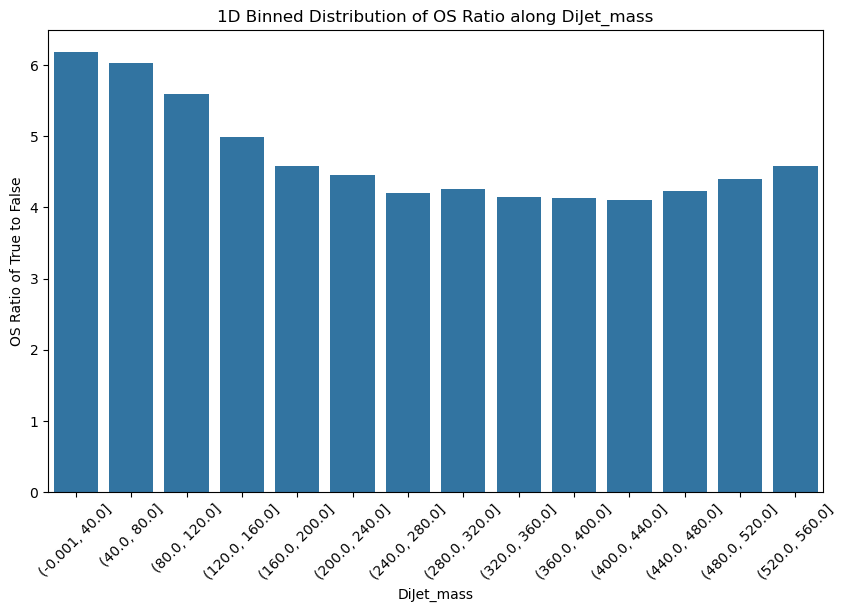

In [38]:
PlotUtil.corr_discrete(df, 'OS', 'DiJet_mass', 15, (0, 600), 'weight')

In [31]:
# further split the data into training and testing based on mass
def split_mass(df_ori):
    df = df_ori.copy()[df_ori['DiJet_mass'] > 80]
    condition = df['DiJet_mass'] > 160
    train = df[condition]
    test = df[~condition]
    return train, test

train_df, val_df = split_mass(df)

In [32]:
def split_mass_three(dfs):
    df = pd.concat(dfs, axis=0)
    condition_1 = df['DiJet_mass'] > 160 
    condition_2 = df['DiJet_mass'] < 220
    train = df[~condition_2]
    test = df[condition_1 & condition_2]
    return train, test

train_df, val_df = split_mass_three([dfA, dfB, dfC, dfD])

In [33]:
cond = train_df['OS'] == False
ss_df = train_df[cond]
os_df = train_df[~cond]

In [34]:
val_cond = val_df['OS'] == False
val_ss_df = val_df[val_cond]
val_os_df = val_df[~val_cond]

In [35]:
from src.utils.mathutil import ABCDUtil
ABCD_Helper = ABCDUtil(val_os_df, os_df, val_ss_df, ss_df, 'weight')
ABCD_Helper.get_all_stats()

          Events (Raw)  Events (Weighted)
Region                                   
Region A         75013               6006
Region B         95059               7501
Region C         16462               1416
Region D         22385               1913
The closure stats for Events (Raw): 
                                  Value
Metric                                 
Predicted events in A    69906 ± 752.71
Prediction/Actual ratio           0.932
Pull significance                13.415
Deviation                         6.785
Percentage difference              6.8%
The closure stats for Events (Weighted): 
                                 Value
Metric                                
Predicted events in A    5553 ± 204.95
Prediction/Actual ratio          0.924
Pull significance                4.221
Deviation                        2.215
Percentage difference             7.6%


In [ ]:
results_dir = "/Users/yuntongzhou/Desktop/Dihiggszztt/output"
drop_kwds = ['Gen', 'weight_values', 'Weight_values', 'OS', 'group', 'gen', 'dataset', 'label', 'btag', 'RecoH_dR', 'id', 'year', 'Tau_charge']
rwgter = SingleXGBReweighter(ss_df, os_df, 'weight', results_dir)
rwgter.prep_data(drop_kwds)

Dropped  294  events with negative weights out of  38847  events.
Dropped  1168  events with negative weights out of  170072  events.
X columns: 
Index(['LDTau_pt', 'LDTau_eta', 'LDTau_phi', 'LDTau_mass', 'LDTau_dxy',
       'LDTau_dz', 'SDTau_pt', 'SDTau_eta', 'SDTau_phi', 'SDTau_mass',
       'SDTau_dxy', 'SDTau_dz', 'LDBjet_pt', 'LDBjet_eta', 'LDBjet_phi',
       'LDBjet_mass', 'SDBjet_pt', 'SDBjet_eta', 'SDBjet_phi', 'SDBjet_mass',
       'DiTau_pt', 'DiTau_eta', 'DiTau_phi', 'DiTau_mass', 'DiJet_pt',
       'DiJet_eta', 'DiJet_phi', 'DiJet_mass', 'Tau_dR', 'Bjet_dR'],
      dtype='object')


[0]	train-logloss:0.49851+0.00084	train-auc:0.66379+0.00170	train-rmse:0.39891+0.00046	test-logloss:0.49987+0.00368	test-auc:0.56804+0.00424	test-rmse:0.39951+0.00206
[20]	train-logloss:0.45815+0.00079	train-auc:0.82128+0.00141	train-rmse:0.38075+0.00043	test-logloss:0.48582+0.00399	test-auc:0.61590+0.00471	test-rmse:0.39328+0.00221
[40]	train-logloss:0.42907+0.00071	train-auc:0.87203+0.00151	train-rmse:0.36722+0.00038	test-logloss:0.48164+0.00422	test-auc:0.62335+0.00580	test-rmse:0.39150+0.00228
[49]	train-logloss:0.41767+0.00062	train-auc:0.88948+0.00199	train-rmse:0.36170+0.00034	test-logloss:0.48062+0.00434	test-auc:0.62612+0.00608	test-rmse:0.39109+0.00231
Optimal number of boosting rounds: 49


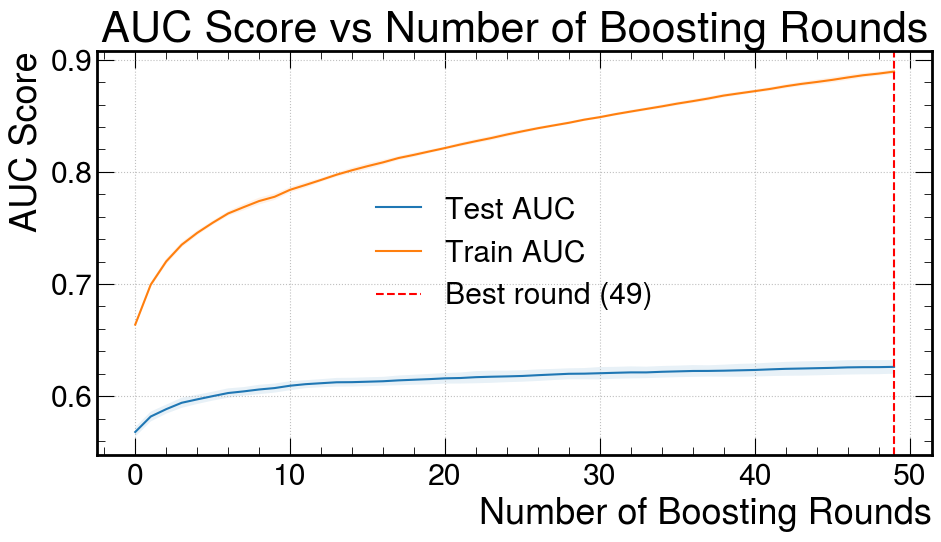

In [ ]:
rwgter.boostingSearch(20, 50, booster='dart')

In [ ]:
rwgter.train(save=True, savename='trained_models/depth_20_dart_fake.json')

[0]	train-logloss:0.49852	test-logloss:0.49714
[40]	train-logloss:0.42853	test-logloss:0.47819
[48]	train-logloss:0.41829	test-logloss:0.47715


ROC AUC Score: 0.628
Accuracy:  0.8159002538641987


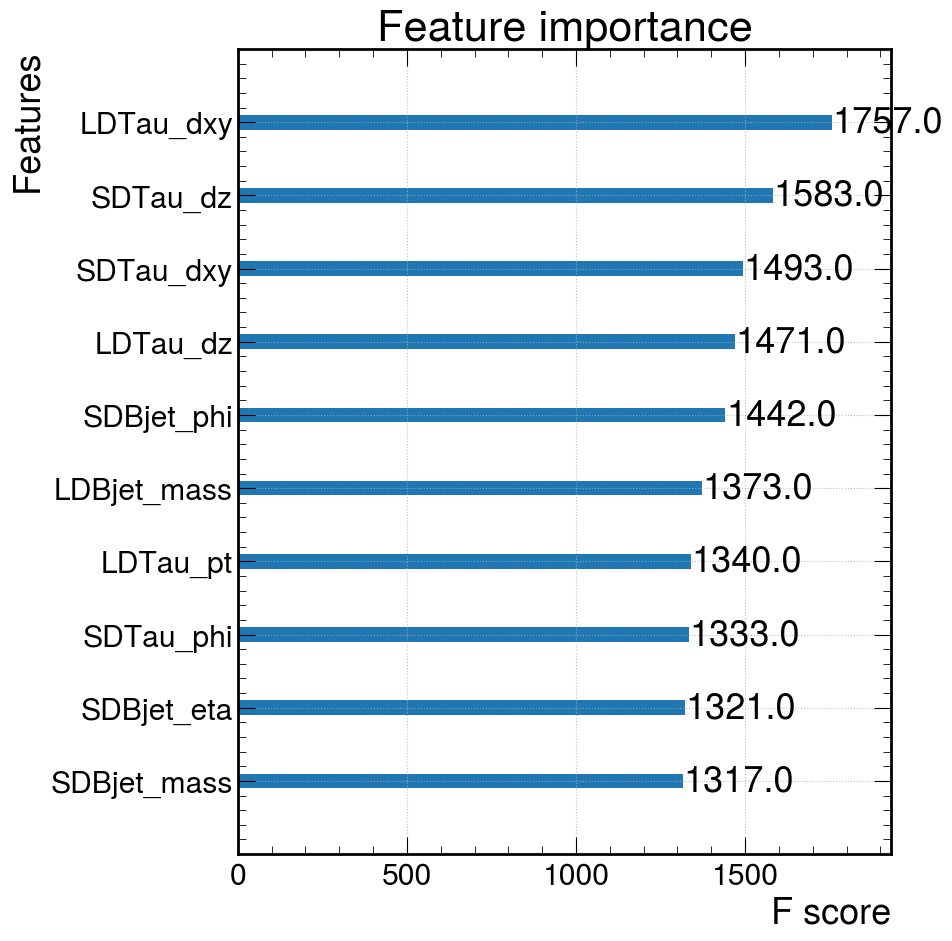

In [ ]:
rwgter.evaluate()

In [ ]:
# Change Naming Here
prefix = 'rwgt'
pjoin = os.path.join
savedir = pjoin('training', 'TTbar_only_fake')

In [ ]:
norm_SS = ss_df['weight'].sum()
norm_OS = os_df['weight'].sum()
rwgt_SS = rwgter.reweight(ss_df, norm_OS, drop_kwds, False)

Dropped  294  events with negative weights out of  38847  events.


In [ ]:
norm_SS_val = val_ss_df['weight'].sum()
norm_OS_val = val_os_df['weight'].sum()
rwgt_SS_val = rwgter.reweight(val_ss_df, norm_OS_val, drop_kwds, False)

Dropped  252  events with negative weights out of  71912  events.


In [ ]:
from src.plotting.visutil import CSVPlotter

In [ ]:
plot_dir_name = 'TTbar_BDT'
out_dir = f'/Users/yuntongzhou/Desktop/Dihiggszztt/output/plots/{plot_dir_name}'
data_dir = f'/Users/yuntongzhou/Desktop/Dihiggszztt/output/{savedir}'

modified_H_mass = {
    "DiTau_mass": {
        "hist": {'bins': 30, 'range': [0,400]},
        "plot": {'xlabel': r'Visible Mass (2$\tau$) (GeV)'}},
    "DiJet_mass": {
        "hist": {'bins': 40, 'range': [160,600]},
        "plot": {'xlabel': r'Invariant Mass (2b) (GeV)'}},
}
from config.plotsetting import tau_pt, dR

/Users/yuntongzhou/Desktop/Dihiggszztt/HHtobbtautau/src/plotting/plothelpers.py:92: RuntimeWarning: invalid value encountered in divide
  ratio = np.nan_to_num(num / den, nan=0., posinf=0.)
/Users/yuntongzhou/Desktop/Dihiggszztt/HHtobbtautau/src/plotting/plothelpers.py:94: RuntimeWarning: invalid value encountered in divide
  ratio * np.sqrt((num_err/num)**2 + (den_err/den)**2),
/Users/yuntongzhou/Desktop/Dihiggszztt/HHtobbtautau/src/plotting/plothelpers.py:92: RuntimeWarning: invalid value encountered in divide
  ratio = np.nan_to_num(num / den, nan=0., posinf=0.)
/Users/yuntongzhou/Desktop/Dihiggszztt/HHtobbtautau/src/plotting/plothelpers.py:94: RuntimeWarning: invalid value encountered in divide
  ratio * np.sqrt((num_err/num)**2 + (den_err/den)**2),
/Users/yuntongzhou/Desktop/Dihiggszztt/HHtobbtautau/src/plotting/plothelpers.py:92: RuntimeWarning: invalid value encountered in divide
  ratio = np.nan_to_num(num / den, nan=0., posinf=0.)
/Users/yuntongzhou/Desktop/Dihiggszztt/HHtobbt

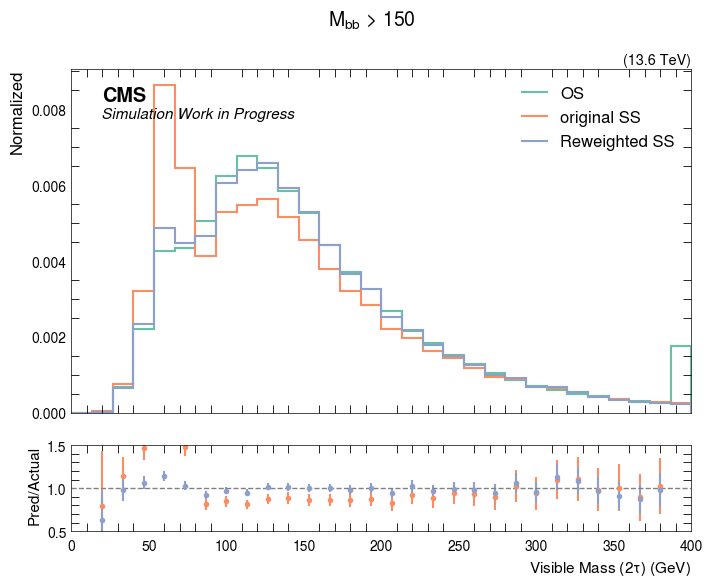

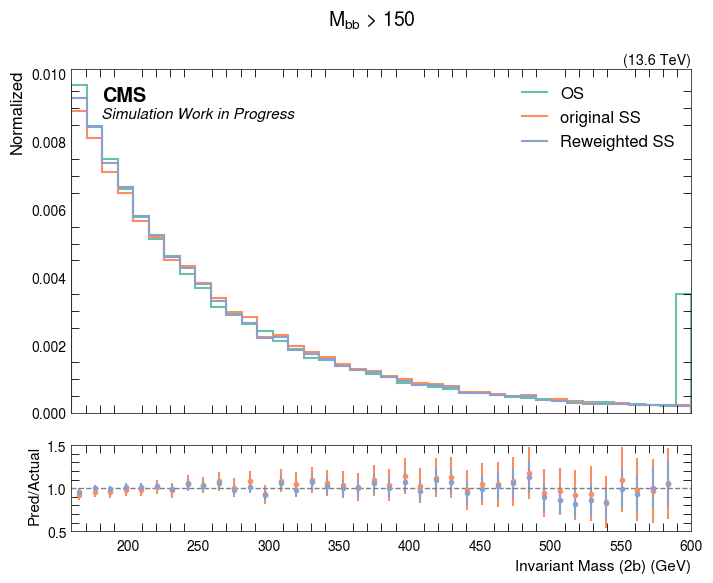

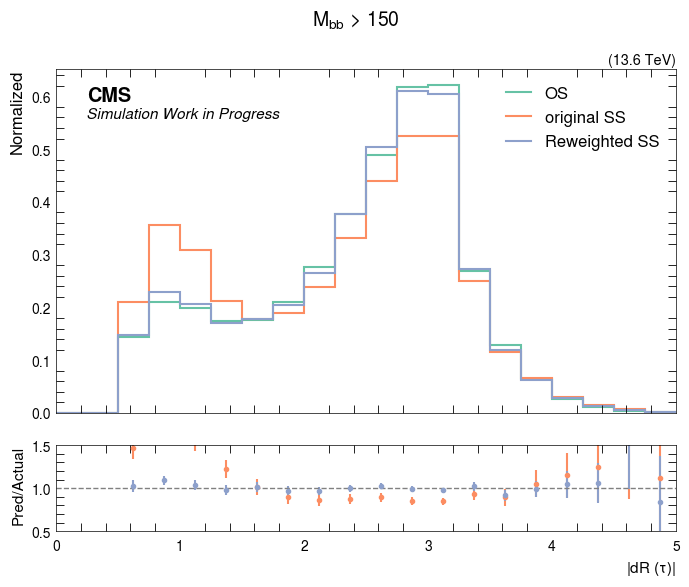

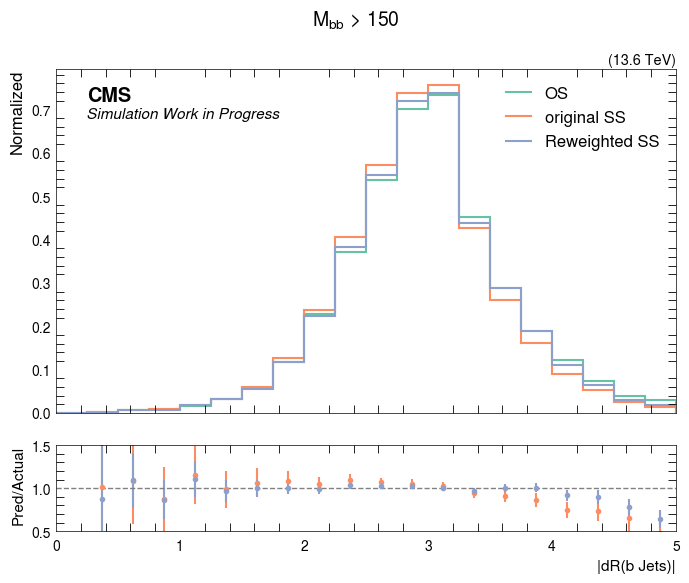

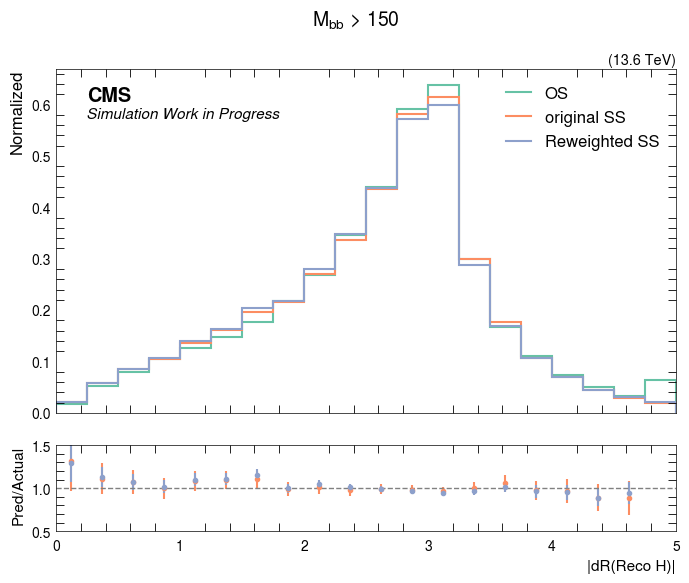

In [ ]:
CSVPlotter.plot_shape([os_df, ss_df, rwgt_SS], ['OS', 'original SS', 'Reweighted SS'], modified_H_mass, 'Pred/Actual', out_dir, title=r'$M_{bb}$ > 150', save_suffix='rwgt')
CSVPlotter.plot_shape([os_df, ss_df, rwgt_SS], ['OS', 'original SS', 'Reweighted SS'], dR, 'Pred/Actual', out_dir, title=r'$M_{bb}$ > 150', save_suffix='rwgt')

/Users/yuntongzhou/Desktop/Dihiggszztt/HHtobbtautau/src/plotting/plothelpers.py:92: RuntimeWarning: invalid value encountered in divide
  ratio = np.nan_to_num(num / den, nan=0., posinf=0.)
/Users/yuntongzhou/Desktop/Dihiggszztt/HHtobbtautau/src/plotting/plothelpers.py:94: RuntimeWarning: invalid value encountered in divide
  ratio * np.sqrt((num_err/num)**2 + (den_err/den)**2),
/Users/yuntongzhou/Desktop/Dihiggszztt/HHtobbtautau/src/plotting/plothelpers.py:92: RuntimeWarning: invalid value encountered in divide
  ratio = np.nan_to_num(num / den, nan=0., posinf=0.)
/Users/yuntongzhou/Desktop/Dihiggszztt/HHtobbtautau/src/plotting/plothelpers.py:94: RuntimeWarning: invalid value encountered in divide
  ratio * np.sqrt((num_err/num)**2 + (den_err/den)**2),
/Users/yuntongzhou/Desktop/Dihiggszztt/HHtobbtautau/src/plotting/plothelpers.py:92: RuntimeWarning: invalid value encountered in divide
  ratio = np.nan_to_num(num / den, nan=0., posinf=0.)
/Users/yuntongzhou/Desktop/Dihiggszztt/HHtobbt

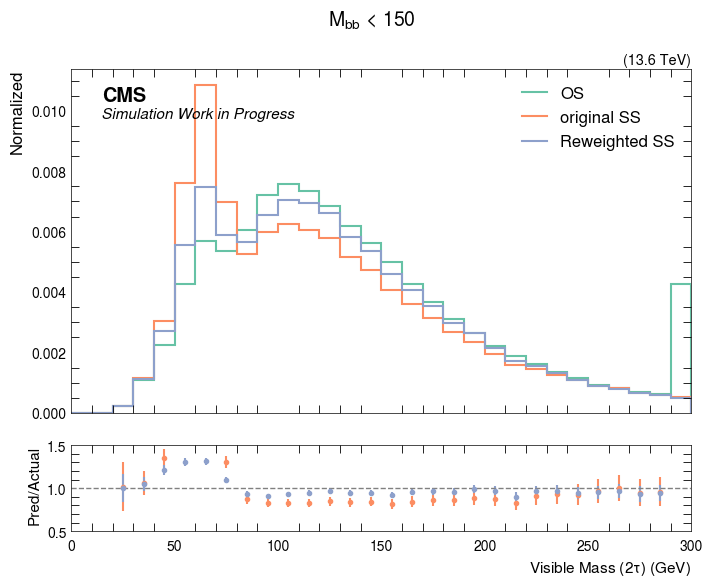

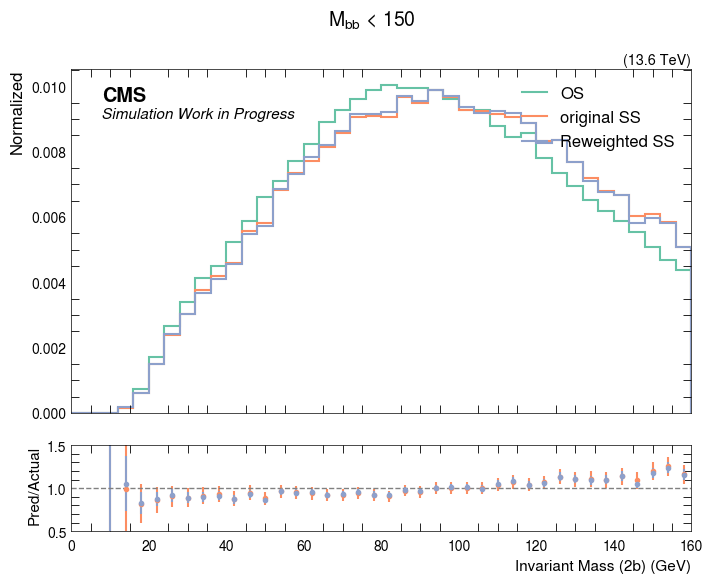

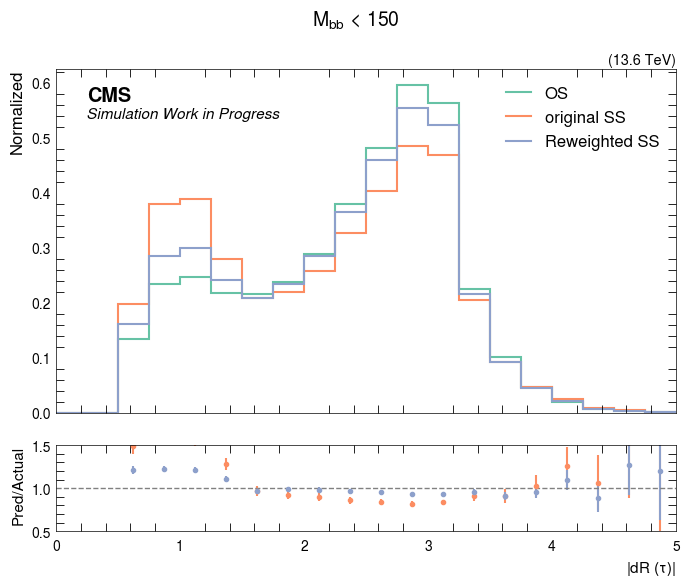

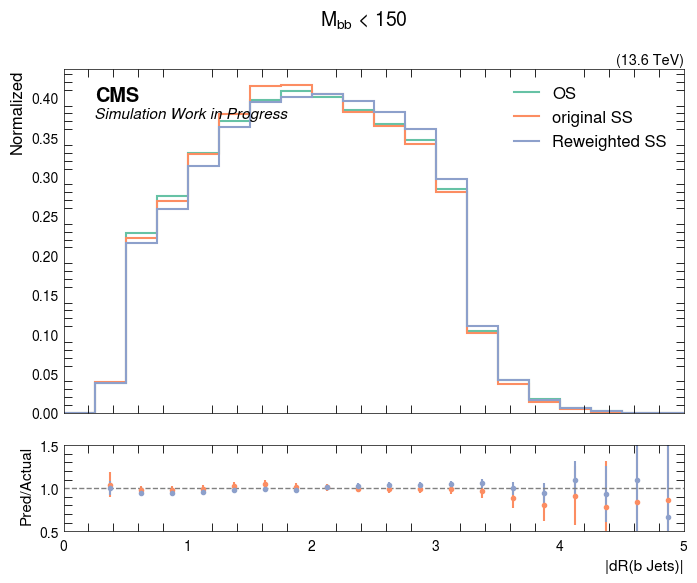

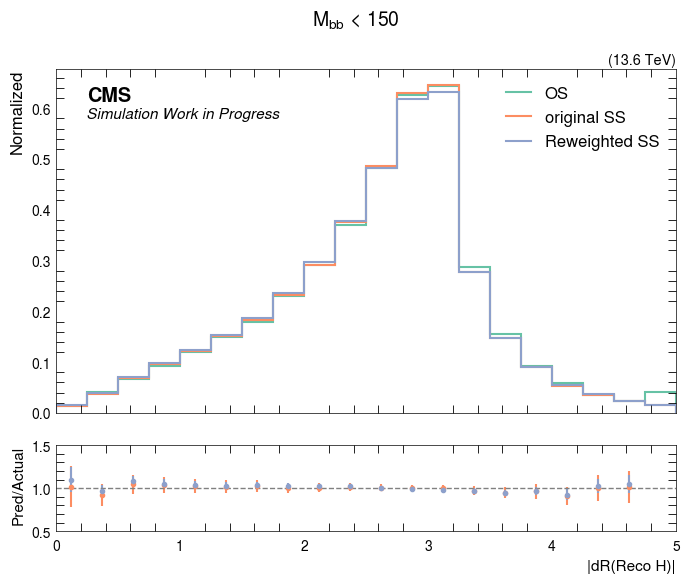

In [ ]:
modified_H_mass = {
    "DiTau_mass": {
        "hist": {'bins': 30, 'range': [0,300]},
        "plot": {'xlabel': r'Visible Mass (2$\tau$) (GeV)'}},
    "DiJet_mass": {
        "hist": {'bins': 40, 'range': [0,160]},
        "plot": {'xlabel': r'Invariant Mass (2b) (GeV)'}},
}
CSVPlotter.plot_shape([val_os_df, val_ss_df, rwgt_SS_val], ['OS', 'original SS', 'Reweighted SS'], modified_H_mass, 'Pred/Actual', out_dir, title=r'$M_{bb}$ < 150', save_suffix='rwgt_sig')
CSVPlotter.plot_shape([val_os_df, val_ss_df, rwgt_SS_val], ['OS', 'original SS', 'Reweighted SS'], dR, 'Pred/Actual', out_dir, title=r'$M_{bb}$ < 150', save_suffix='rwgt_sig')